# Delta Classification CNN
## GEOG 6160 Final Project
## Magnus Tveit

Trains a Convolutional Neural Network to classify 8×8 Landsat chips as **delta** or **not_delta**.

**Prerequisites:** Run `DeltaExtractChips.ipynb` first to populate `Chips/`.

Pipeline:
1. Load `.npy` chips from `Chips/train`, `valid`, `test`
2. Visualise a sample of training chips
3. Build and train the CNN
4. Plot training curves
5. Evaluate on the held-out test set (accuracy, precision, recall, confusion matrix)
6. Save best model as `delta_model.keras` → used by `DeltaPredict.ipynb`

### Set Up

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow version:", tf.__version__)

2026-03-16 10:17:34.090914: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 10:17:36.537694: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-16 10:17:47.019638: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0


### Settings

In [2]:
base_dir  = os.getcwd()
chips_dir = os.path.join(base_dir, "Chips")

# Image dimensions — must match CHIP_SIZE in ExtractChips
IMAGE_HEIGHT = 8
IMAGE_WIDTH  = 8
NUM_CHANNELS = 7   # B2, B3, B4, B5, B6, NDVI, NDWI

# Class order matches folder names sorted alphabetically: delta < not_delta
CLASSES     = ["delta", "not_delta"]
NUM_CLASSES = len(CLASSES)

BATCH_SIZE = 16
EPOCHS     = 50

print(f"Input shape : ({IMAGE_HEIGHT}, {IMAGE_WIDTH}, {NUM_CHANNELS})")
print(f"Classes     : {CLASSES}")

Input shape : (8, 8, 7)
Classes     : ['delta', 'not_delta']


### Load chips

In [3]:
def load_chips(split):
    """Load all chips for train / valid / test and return (X, Y) arrays."""
    X_list, Y_list = [], []
    for class_idx, cls in enumerate(CLASSES):
        cls_dir = os.path.join(chips_dir, split, cls)
        files   = sorted([f for f in os.listdir(cls_dir) if f.endswith(".npy")])
        print(f"  {split}/{cls}: {len(files)} chips")
        for fname in files:
            chip = np.load(os.path.join(cls_dir, fname)).astype("float32")
            X_list.append(chip)
            # One-hot encode the label
            label = np.zeros(NUM_CLASSES, dtype="float32")
            label[class_idx] = 1.0
            Y_list.append(label)
    return np.stack(X_list), np.stack(Y_list)

X_train, y_train = load_chips("train")
X_val,   y_val   = load_chips("valid")
X_test,  y_test  = load_chips("test")
print(f"\nX_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")

  train/delta: 151 chips
  train/not_delta: 604 chips
  valid/delta: 32 chips
  valid/not_delta: 129 chips
  test/delta: 33 chips
  test/not_delta: 131 chips

X_train : (755, 8, 8, 7)  y_train : (755, 2)
X_val   : (161, 8, 8, 7)    y_val   : (161, 2)
X_test  : (164, 8, 8, 7)   y_test  : (164, 2)


### Visualise chips
Displays a random sample of training chips as NIR/Red/Green false colour composites to sanity-check the extracted data before training.

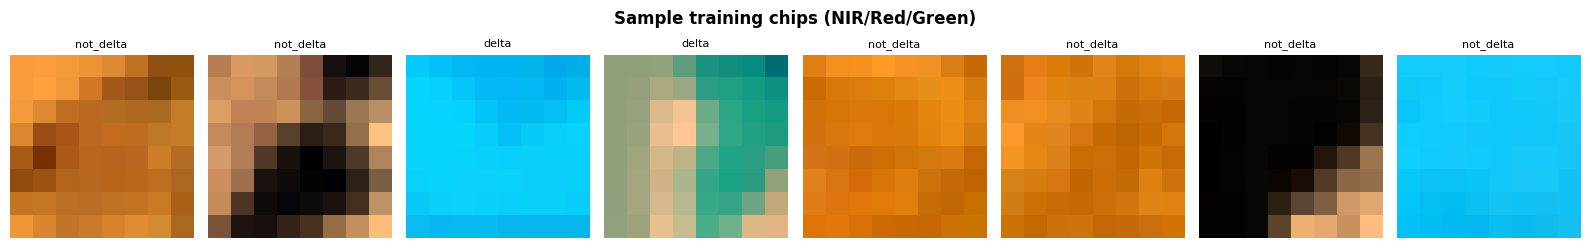

In [4]:
def show_chips(X, Y, n=8, title=""):
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
    indices = np.random.choice(len(X), n, replace=False)
    for ax, idx in zip(axes, indices):
        # Band indices: NIR=3, Red=2, Green=1 (0-indexed within the 7-band stack)
        rgb = X[idx][:, :, [3, 2, 1]]
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        ax.imshow(rgb)
        ax.set_title(CLASSES[np.argmax(Y[idx])], fontsize=8)
        ax.axis("off")
    plt.suptitle(title, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_chips(X_train, y_train, title="Sample training chips (NIR/Red/Green)")

### Build CNN
Three Conv2D → MaxPool → BatchNorm blocks progressively extract spatial features,
followed by two Dense + Dropout layers for classification.

- Filters double each block (32 → 64 → 128) to capture increasingly abstract features
- `Dropout(0.4)` reduces overfitting on the small dataset
- Final `softmax` layer outputs a probability for each class

In [5]:
model = models.Sequential([
    layers.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, NUM_CHANNELS)),

    # Block 1 — low-level edge and colour features
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    # Block 2 — intermediate texture features
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    # Block 3 — higher-level spectral patterns
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    # Classifier head
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])
model.summary()

2026-03-16 10:17:52.733854: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 32)       │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 4, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2, 2, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 1, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,194 (469.51 KB)

 Trainable params: 119,746 (467.76 KB)

 Non-trainable params: 448 (1.75 KB)

### Compile
Adam with a low learning rate keeps training stable on a small dataset. `ModelCheckpoint` saves only the epoch with the lowest validation loss.

In [6]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = tf.keras.losses.CategoricalCrossentropy(),
    metrics   = ["accuracy"]
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath       = os.path.join(base_dir, "delta_model.keras"),
        save_best_only = True,   # only overwrite if val_loss improves
        monitor        = "val_loss",
        verbose        = 1
    )
]

### Train

In [7]:
history = model.fit(
    x=X_train, y=y_train,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    shuffle=True,
    callbacks=callbacks
)

Epoch 1/50


47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5584 - loss: 0.7311
Epoch 1: val_loss improved from None to 0.69554, saving model to /uufs/chpc.utah.edu/common/home/u0972368/SpatialDataScience/Delta/delta_model.keras

Epoch 1: finished saving model to /uufs/chpc.utah.edu/common/home/u0972368/SpatialDataScience/Delta/delta_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.6861 - loss: 0.5626 - val_accuracy: 0.2298 - val_loss: 0.6955
Epoch 2/50
43/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8676 - loss: 0.3219
Epoch 2: val_loss improved from 0.69554 to 0.61739, saving model to /uufs/chpc.utah.edu/common/home/u0972368/SpatialDataScience/Delta/delta_model.keras

Epoch 2: finished saving model to /uufs/chpc.utah.edu/common/home/u0972368/SpatialDataScience/Delta/delta_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8861 - loss: 0.2827 - val_accuracy: 0.8012 - val_loss: 0.6174
Epoch 3/50
45/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9264 - 

### Training curves

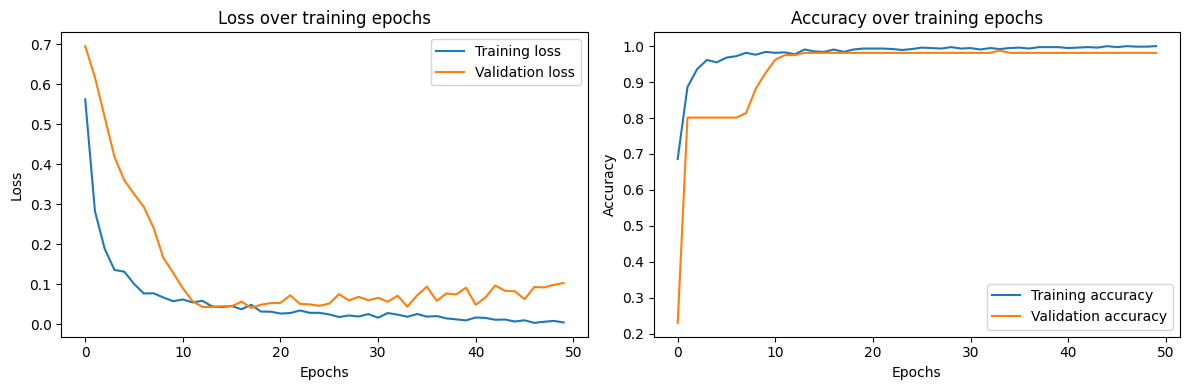

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"],     label="Training loss")
ax1.plot(history.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epochs"); ax1.set_ylabel("Loss")
ax1.set_title("Loss over training epochs"); ax1.legend()

ax2.plot(history.history["accuracy"],     label="Training accuracy")
ax2.plot(history.history["val_accuracy"], label="Validation accuracy")
ax2.set_xlabel("Epochs"); ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy over training epochs"); ax2.legend()

plt.tight_layout(); plt.show()

### Evaluate
Evaluate using the test set

In [9]:
best_model = keras.models.load_model(os.path.join(base_dir, "delta_model.keras"))
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")

Test loss     : 0.0662
Test accuracy : 0.9878


### Precision, recall and confusion matrix

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Precision : 0.9714
Recall    : 0.9924


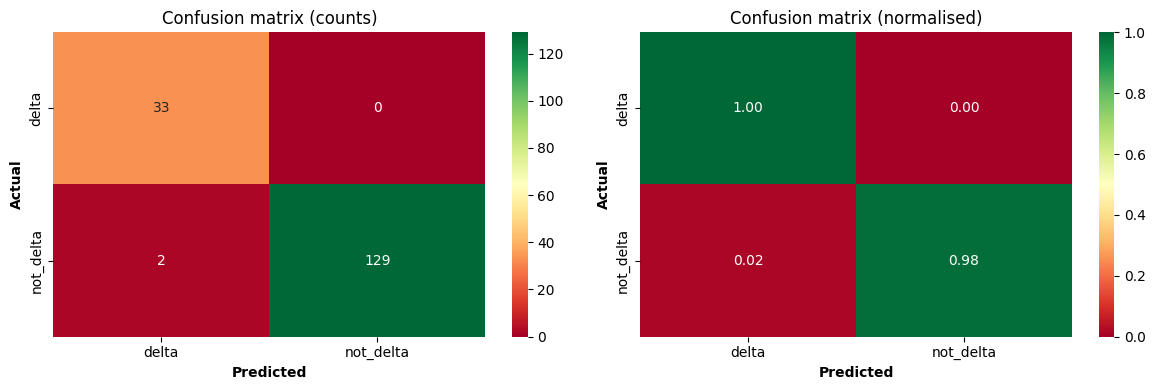

In [10]:
y_pred_probs = best_model.predict(X_test)
y_pred   = np.argmax(y_pred_probs, axis=1)
y_actual = np.argmax(y_test,       axis=1)

print(f"Precision : {precision_score(y_actual, y_pred, average='macro'):.4f}")
print(f"Recall    : {recall_score(   y_actual, y_pred, average='macro'):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, norm, title in zip(axes, [None, "true"],
                            ["Confusion matrix (counts)",
                             "Confusion matrix (normalised)"]):
    cm  = confusion_matrix(y_actual, y_pred, normalize=norm)
    fmt = "d" if norm is None else ".2f"
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="RdYlGn",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_xlabel("Predicted", fontweight="bold")
    ax.set_ylabel("Actual",    fontweight="bold")
    ax.set_title(title)
plt.tight_layout(); plt.show()

### Visualise test chip predictions

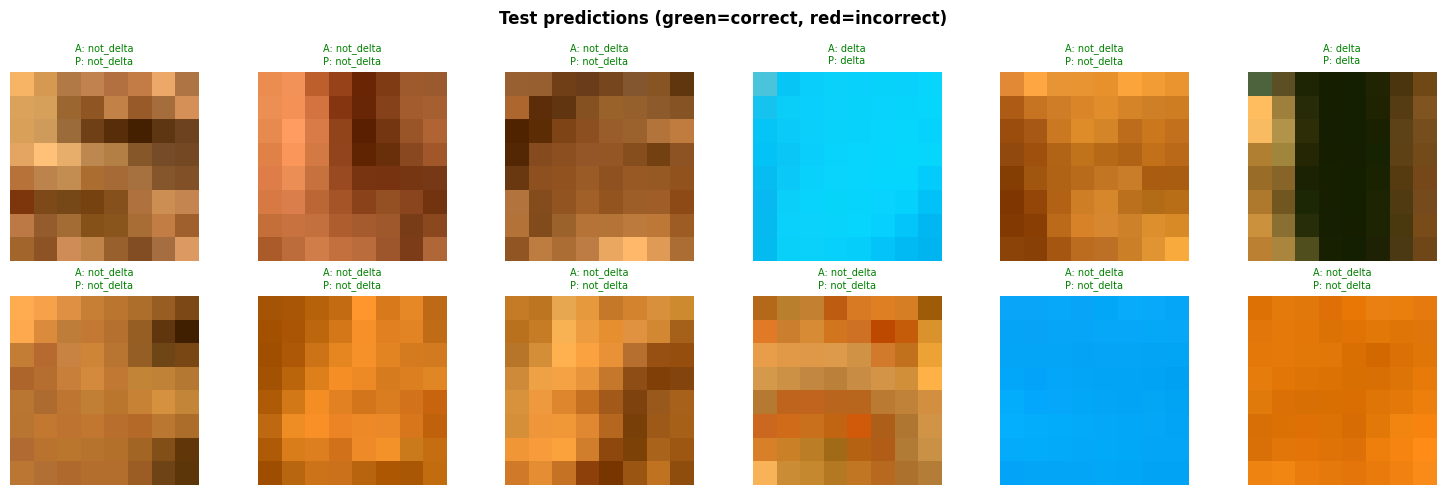


Done. Ready for DeltaPredict.ipynb


In [11]:
n_show  = 12
indices = np.random.choice(len(X_test), n_show, replace=False)
fig, axes = plt.subplots(2, n_show // 2, figsize=(2.5 * (n_show // 2), 5))
axes = axes.flatten()

for ax, idx in zip(axes, indices):
    rgb = X_test[idx][:, :, [3, 2, 1]]
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    ax.imshow(rgb)
    actual_lbl    = CLASSES[y_actual[idx]]
    predicted_lbl = CLASSES[y_pred[idx]]
    colour = "green" if actual_lbl == predicted_lbl else "red"
    ax.set_title(f"A: {actual_lbl}\nP: {predicted_lbl}", fontsize=7, color=colour)
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_edgecolor(colour); spine.set_linewidth(3)

plt.suptitle("Test predictions (green=correct, red=incorrect)", fontweight="bold")
plt.tight_layout(); plt.show()

print("\nDone. Ready for DeltaPredict.ipynb")